In [1]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap

In [3]:
galaxy_idx = 30

galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[galaxy_idx])
with h5py.File(f"data/turb-vels/{nicegalaxy.galaxies[galaxy_idx]}.h5", "r") as f:
    turb = dict()
    for key in f:
        turb[key] = np.array(f[key])

In [4]:
cell_radii = (3/(4*np.pi) * galaxy.gas["Masses"]/galaxy.gas["Density"])**(1/3)

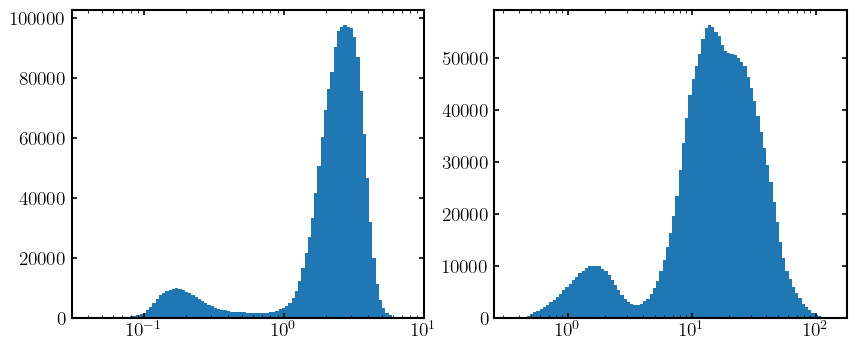

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
bins = np.logspace(np.log10(cell_radii.min()), np.log10(cell_radii.max()), 100)
axs[0].hist(cell_radii, bins=bins)
axs[0].set_xscale("log")

bins = np.logspace(np.log10(turb["CoherenceScale"].min()), np.log10(turb["CoherenceScale"].max()), 100)
axs[1].hist(turb["CoherenceScale"], bins=bins)
axs[1].set_xscale("log")

Text(0.5, 1.0, 'Cells in 300kpc-320kpc radial shell')

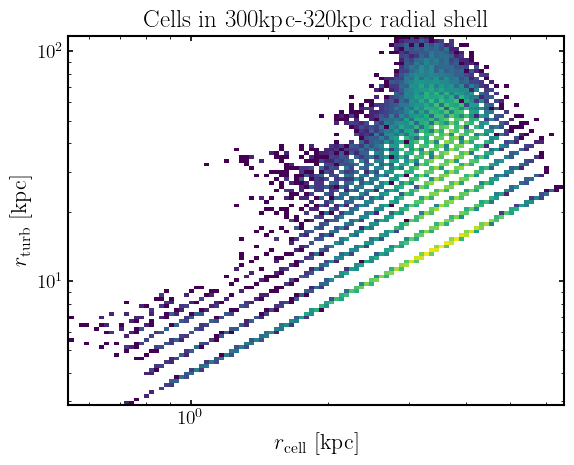

In [17]:
distances = np.linalg.norm(galaxy.gas["Coordinates"] - galaxy.bhs["Coordinates"][0], axis=-1) 
dist_mask = (distances > 300) & (distances < 320)

xbins = np.logspace(np.log10(cell_radii[dist_mask].min()), np.log10(cell_radii[dist_mask].max()), 100)
ybins = np.logspace(np.log10(turb["CoherenceScale"][dist_mask].min()), np.log10(turb["CoherenceScale"][dist_mask].max()), 100)
plt.hist2d(cell_radii[dist_mask], turb["CoherenceScale"][dist_mask], bins=[xbins, ybins], norm="log")
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$r_{\mathrm{cell}}$ [kpc]")
plt.ylabel(r"$r_{\mathrm{turb}}$ [kpc]")
plt.title("Cells in 300kpc-320kpc radial shell")